# Ансамблевая классификация

**Выполнил**: *Никончук В.И. ЕТ-443*

**Постановка задачи**:

1. Разработайте программу, которая выполняет классификацию заданного набора данных с помощью одной из техник ансамблевой классификации. Параметрами программы являются набор данных, ансамблевая техника (бэггинг, случайный лес или бустинг), количество участников ансамбля, а также параметры в соответствии с выбранной техникой ансамблевой классификации.

2. Проведите эксперименты на наборе данных из задания Классификация с помощью дерева решений, варьируя количество участников ансамбля (от 50 до 100 с шагом 10).

3. Выполните визуализацию полученных результатов в виде следующих диаграмм:
 - показатели качества классификации в зависимости от количества участников ансамбля для заданного набора данных; 
 - нанесите на диаграмму соответствующие значения, полученные в задании Классификация с помощью дерева решений.

4. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
 - формулировка задания; 
 - гиперссылка на каталог репозитория с исходными текстами, наборами данных и др. сопутствующими материалами; 
 - рисунки с результатами визуализации; 
 - пояснения, раскрывающие смысл полученных результатов.

## Подключение библиотек

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from typing import Callable, Dict, List
from numpy.typing import ArrayLike

## Чтение данных

Загрузка датасета.

> Датасет уже должен бил быть загружен при выполнении 3 задания.

```shellscript
wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names
wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test
wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
```

In [198]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 
    'hours-per-week', 'native-country', 'annual_income'
]

data_df = pd.concat([
    pd.read_csv('../3-DecisionTree/adult.data', names=column_names),
    pd.read_csv('../3-DecisionTree/adult.test', names=column_names, skiprows=1)
])

print(data_df.info())
data_df.describe()

<class 'pandas.DataFrame'>
Index: 48842 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      48842 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  str  
 14  annual_income   48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.0 MB
None


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [199]:
y_df = data_df.pop('annual_income')

print(y_df.head(5))
data_df.head(5)

0     <=50K
1     <=50K
2     <=50K
3     <=50K
4     <=50K
Name: annual_income, dtype: str


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [200]:
def print_unique_value_counts(dict: dict[str, pd.Series[int]]) -> None:
    for label, counts in dict.items():    
        print(f"{'='*40}")
        print(f"Столбец: {label}")
        print(f"Всего уникальных значений: {len(counts)}")
        print(f"{'='*40}")
        
        for value, count in counts.items():
            percent = (count / len(data_df)) * 100
            print(f"  '{value}': {count} ({percent:.2f}%)")
        print()

In [201]:
str_labels = data_df.select_dtypes(include=['object', 'str']).columns.tolist()
label_to_counts = {label: data_df[label].value_counts() for label in str_labels}
label_to_counts['annual_income'] = y_df.value_counts()

print_unique_value_counts(label_to_counts)

Столбец: workclass
Всего уникальных значений: 9
  ' Private': 33906 (69.42%)
  ' Self-emp-not-inc': 3862 (7.91%)
  ' Local-gov': 3136 (6.42%)
  ' ?': 2799 (5.73%)
  ' State-gov': 1981 (4.06%)
  ' Self-emp-inc': 1695 (3.47%)
  ' Federal-gov': 1432 (2.93%)
  ' Without-pay': 21 (0.04%)
  ' Never-worked': 10 (0.02%)

Столбец: education
Всего уникальных значений: 16
  ' HS-grad': 15784 (32.32%)
  ' Some-college': 10878 (22.27%)
  ' Bachelors': 8025 (16.43%)
  ' Masters': 2657 (5.44%)
  ' Assoc-voc': 2061 (4.22%)
  ' 11th': 1812 (3.71%)
  ' Assoc-acdm': 1601 (3.28%)
  ' 10th': 1389 (2.84%)
  ' 7th-8th': 955 (1.96%)
  ' Prof-school': 834 (1.71%)
  ' 9th': 756 (1.55%)
  ' 12th': 657 (1.35%)
  ' Doctorate': 594 (1.22%)
  ' 5th-6th': 509 (1.04%)
  ' 1st-4th': 247 (0.51%)
  ' Preschool': 83 (0.17%)

Столбец: marital-status
Всего уникальных значений: 7
  ' Married-civ-spouse': 22379 (45.82%)
  ' Never-married': 16117 (33.00%)
  ' Divorced': 6633 (13.58%)
  ' Separated': 1530 (3.13%)
  ' Widowed': 

> Преобразуем значения `<=50K.` и `>50K.`, убрав точки в конце

In [202]:
y_df = y_df.apply(lambda x: x.replace('.', '') if x[-1] == "." else x)

print(y_df.unique())

<StringArray>
[' <=50K', ' >50K']
Length: 2, dtype: str


## Предобработка данных

Для выполнения вычислений требуется сначала предобработать данные. 

Т.к. деревья решений не чувствительны к размерности, разбросу входных данных, то проводить нормализацию значений не нужно.

Т.к. в ходных данных нету пропусков, то обрабатывать их тоже не нужно.

> Необходимо только лишь произвести перевод строковых значений в числовые. Воспользуемся для этого `LabelEncoder`

In [203]:
class DataNormalizer:
    def __init__(self, X: pd.DataFrame, y: pd.Series):
        self.encodeable_X_labels = X.select_dtypes(include=['str']).columns.tolist()
        self.y_is_encodeable = y.dtype == 'str'

        self.encoders_for_X_columns = {
            label: LabelEncoder().fit(X[label]) for label in self.encodeable_X_labels
        }
        
        if self.y_is_encodeable:
            self.y_encoder = LabelEncoder().fit(y)
        else:
            self.y_encoder = None
    
    def transform(self, X: pd.DataFrame, y: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
        return self._apply_transformation(
            X, y, 
            lambda encoder, data: encoder.transform(data)
        )

    def inverse_transform(self, X:pd.DataFrame, y: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
        return self._apply_transformation(
            X, y, 
            lambda encoder, data: encoder.inverse_transform(data)
        )

    def _apply_transformation(
            self, X: pd.DataFrame, y: pd.Series, 
            transform_fn: Callable[[LabelEncoder, ArrayLike], ArrayLike]) -> tuple[pd.DataFrame, pd.Series]:
        transformed_X = X.copy()
        for label in self.encodeable_X_labels:
            encoder = self.encoders_for_X_columns[label]
            transformed = transform_fn(encoder, X[label])
            transformed_X[label] = pd.Series(transformed)
        
        if self.y_encoder is not None:
            transformed_y = pd.Series(
                data=np.array(transform_fn(self.y_encoder, y)), 
                index=y.index, 
                name=y.name,
                dtype=np.int64
            )
        else:
            transformed_y = y.copy()
        
        return transformed_X, transformed_y



In [204]:
normalizer = DataNormalizer(data_df, y_df)

data_df, y_df = normalizer.transform(data_df, y_df)

In [205]:
label_to_counts = {label: data_df[label].value_counts() for label in str_labels}
label_to_counts['annual_income'] = y_df.value_counts()

print_unique_value_counts(label_to_counts)

Столбец: workclass
Всего уникальных значений: 9
  '4': 34036 (69.69%)
  '6': 3826 (7.83%)
  '2': 3111 (6.37%)
  '0': 2752 (5.63%)
  '7': 1960 (4.01%)
  '5': 1678 (3.44%)
  '1': 1451 (2.97%)
  '8': 18 (0.04%)
  '3': 10 (0.02%)

Столбец: education
Всего уникальных значений: 16
  '11': 15823 (32.40%)
  '15': 10952 (22.42%)
  '9': 8052 (16.49%)
  '12': 2591 (5.30%)
  '8': 2062 (4.22%)
  '1': 1761 (3.61%)
  '7': 1583 (3.24%)
  '0': 1394 (2.85%)
  '5': 964 (1.97%)
  '14': 851 (1.74%)
  '6': 760 (1.56%)
  '10': 615 (1.26%)
  '2': 614 (1.26%)
  '4': 497 (1.02%)
  '3': 250 (0.51%)
  '13': 73 (0.15%)

Столбец: marital-status
Всего уникальных значений: 7
  '2': 22445 (45.95%)
  '4': 16042 (32.84%)
  '0': 6670 (13.66%)
  '5': 1532 (3.14%)
  '6': 1485 (3.04%)
  '3': 633 (1.30%)
  '1': 35 (0.07%)

Столбец: occupation
Всего уникальных значений: 15
  '10': 6202 (12.70%)
  '3': 6116 (12.52%)
  '4': 6058 (12.40%)
  '1': 5743 (11.76%)
  '12': 5521 (11.30%)
  '8': 4951 (10.14%)
  '7': 3025 (6.19%)
  '0': 

In [206]:
print(data_df.info())

<class 'pandas.DataFrame'>
Index: 48842 entries, 0 to 16280
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       48842 non-null  int64
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  int64
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  int64
 6   occupation      48842 non-null  int64
 7   relationship    48842 non-null  int64
 8   race            48842 non-null  int64
 9   sex             48842 non-null  int64
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48842 non-null  int64
dtypes: int64(14)
memory usage: 5.6 MB
None


> Предобработка данных успешно завершена. Теперь данные готовы к обработке

## Разбиение выборки

Разобьем выборку данных на тренировочную и тестовую с соотношением 70/30.

In [207]:
X_train, X_test, y_train, y_test = train_test_split(
    data_df, y_df, train_size=0.7, random_state=35, stratify=y_df)
X_train, X_test, y_train, y_test = (
    pd.DataFrame(X_train), pd.DataFrame(X_test), pd.Series(y_train), pd.Series(y_test))

print(f'Количество тренировочных данных: {X_train.shape[0]}')
print(f"Количество тестировочных данных: {X_test.shape[0]}")

Количество тренировочных данных: 34189
Количество тестировочных данных: 14653


# **Задание 1**

1. Разработайте программу, которая выполняет классификацию заданного набора данных с помощью одной из техник ансамблевой классификации. Параметрами программы являются набор данных, ансамблевая техника (бэггинг, случайный лес или бустинг), количество участников ансамбля, а также параметры в соответствии с выбранной техникой ансамблевой классификации.

In [208]:
class EnsembleClassifier:

    def __init__(self, model_type: str, 
                 max_participants: int | None = None, 
                 **kwargs):
        if (model_type not in ['bagging', 'random_forest', 'boosting'] or
        max_participants != None and max_participants < 1):
            raise Exception("Параметры определены неверно")
        
        if max_participants == None:
            max_participants = 100
        
        common_params = {
            'random_state': 35,
        }
        
        if model_type == 'bagging':
            base_estimator = DecisionTreeClassifier(
                class_weight='balanced', 
                random_state=35
            )
            self.model = BaggingClassifier(
                estimator=base_estimator,
                n_estimators=max_participants, 
                n_jobs = -1,
                **common_params, **kwargs
            )
        elif model_type == 'random_forest':
            self.model = RandomForestClassifier(
                n_estimators=max_participants, 
                n_jobs=-1,
                class_weight='balanced',
                **common_params, **kwargs
            )
        else:
            self.model = HistGradientBoostingClassifier(
                max_iter=max_participants,
                early_stopping=True,
                class_weight='balanced',
                **common_params, **kwargs
            )
    
    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        self.model.fit(X_train, y_train)
    
    def predict(self, X: pd.DataFrame):
        y_pred = self.model.predict(X)
        return pd.Series(y_pred)

In [209]:
class Visualiser:
    def __init__(self):
        self.metrics_labels = ['accuracy', "precision", "recall", "f1_score"]
        self.metrics = {label: [] for label in self.metrics_labels}
    
    def add_metrics(self, local_metrics: Dict[str, float]) -> None:
        for label in self.metrics_labels:
            self.metrics[label].append(local_metrics[label])

    @staticmethod
    def calc_metrics(true_y: pd.Series, y_pred: pd.Series) -> Dict[str, float]:
        local_metrics = dict()
        local_metrics["accuracy"] = accuracy_score(true_y, y_pred)
        local_metrics["precision"] = precision_score(true_y, y_pred)
        local_metrics["recall"] = recall_score(true_y, y_pred)
        local_metrics["f1_score"] = f1_score(true_y, y_pred)
        
        return local_metrics
    
    @staticmethod
    def visualise_confusion_matrix(true_y: pd.Series, predicted_y: pd.Series) -> None:
        conf_matrix = confusion_matrix(true_y, predicted_y)
        display = ConfusionMatrixDisplay(conf_matrix, display_labels=['0', '1'])
        display.plot()
    
    def visualise_metrics(
            self, 
            X: List[int], 
            suptitle: str, 
            xlabel: str,
            pin_other_metric: Dict[str, float] | None = None,
            other_metric_label: str | None = None,
            set_y_lim: bool = False
            ) -> None:
        main_color = 'blue'
        other_color = 'red'

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        for i in range(2):
            for j in range(2):
                index = i * 2 + j
                label = self.metrics_labels[index]
                axes[i,j].plot(X, self.metrics[label], marker='o', color=main_color, label='Основная модель')

                if pin_other_metric and label in pin_other_metric:
                    axes[i, j].axhline(
                        y=pin_other_metric[label], 
                        color=other_color, 
                        linestyle='--', 
                        linewidth=2, 
                        label=other_metric_label or 'Дополнительная метрика'
                    )

                axes[i,j].set_title(label)
                axes[i,j].set_xlabel(xlabel)
                axes[i,j].set_ylabel('Значение метрики')
                if set_y_lim:
                    axes[i, j].set_ylim(0, 1)
                axes[i,j].grid(True, linestyle='--')

                if pin_other_metric and label in pin_other_metric:
                    axes[i, j].legend()
        
        fig.suptitle(suptitle)

    def visualise_metrics_with_bars(
            self, 
            methods_names: List[str], 
            ) -> None:        
        data = []
        for i, name in enumerate(methods_names):
            for label in self.metrics_labels:
                data.append({'Модель': name, 'Metric': label, 'Value': self.metrics[label][i]})
        
        df = pd.DataFrame(data)
        sns.barplot(data=df, x='Metric', y='Value', hue='Модель')
        plt.ylim(0, 1)
        plt.show()

In [210]:
def сonduct_experiment(
        model_type: str,
        max_participants: int | None = None,
        print_metrics: bool = True,
        visualise_conf_matrix: bool = True,
        ) -> Dict[str, float]:
    classifier = EnsembleClassifier(model_type, max_participants=max_participants)
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    metrics = Visualiser.calc_metrics(y_test, y_pred)

    if print_metrics:
        print("*"*50, model_type, "*"*50, sep="\n")
        for label in metrics.keys():
            print(f"{label}: {metrics[label]}")
    
    if visualise_conf_matrix:
        Visualiser.visualise_confusion_matrix(y_test, y_pred)
    
    return metrics

**************************************************
bagging
**************************************************
accuracy: 0.8419436292909301
precision: 0.7267530487804879
recall: 0.5439247005134056
f1_score: 0.6221859706362153


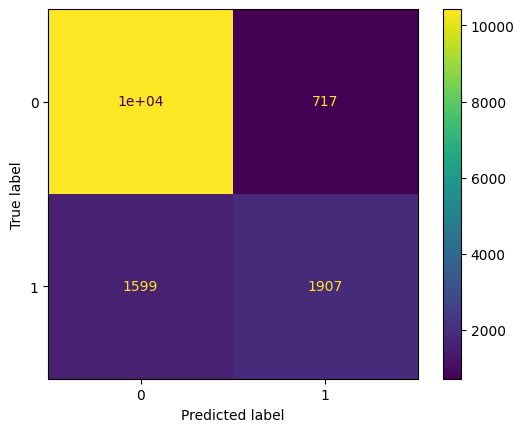

In [211]:
visualizer = Visualiser()

metrics = сonduct_experiment('bagging')
visualizer.add_metrics(metrics)

**************************************************
random_forest
**************************************************
accuracy: 0.8459701085102027
precision: 0.7471309853581322
recall: 0.5385054192812322
f1_score: 0.6258909332007293


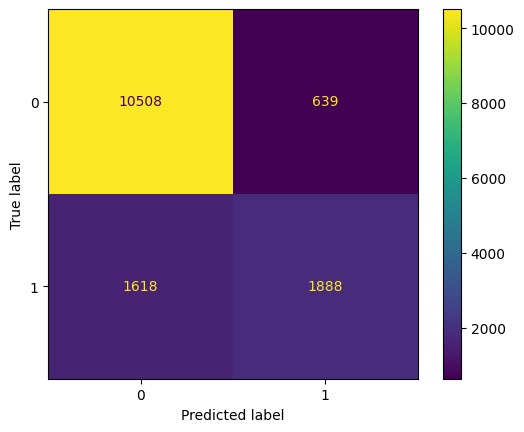

In [212]:
metrics = сonduct_experiment('random_forest')
visualizer.add_metrics(metrics)

**************************************************
boosting
**************************************************
accuracy: 0.8039309356445778
precision: 0.5613490986625315
recall: 0.8260125499144324
f1_score: 0.6684362377380265


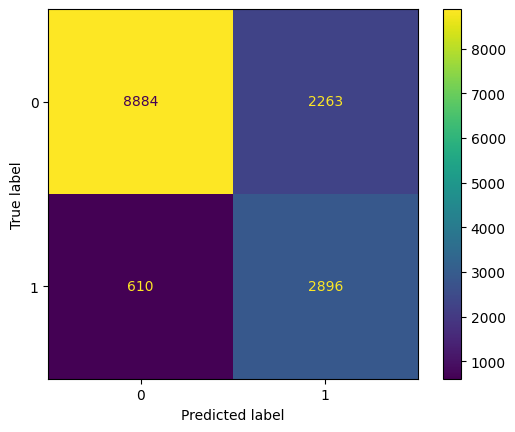

In [213]:
metrics = сonduct_experiment('boosting')
visualizer.add_metrics(metrics)

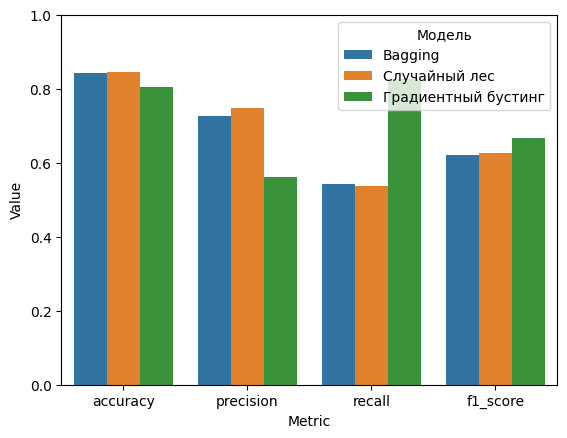

In [214]:
visualizer.visualise_metrics_with_bars(methods_names=["Bagging", "Случайный лес", "Градиентный бустинг"])

> В проведенном эксперименте лучше всего себя показал алгоритм градиентного бустинга. Хоть он и имеет меньшую прециозность (`precision`) чем остальные алгоритмы, очень высокая полнота делает f1_score наибольшим среди всех представленных. Именно алгоритм градиентного бустинга лучше будет предсказывать "богатых" людей, хоть и немного чаще остальных будет делать "бедных" "богатыми".

# **Задание 2, 3**

2. Проведите эксперименты на наборе данных из задания Классификация с помощью дерева решений, варьируя количество участников ансамбля (от 50 до 100 с шагом 10).

3. Выполните визуализацию полученных результатов в виде следующих диаграмм:
 - показатели качества классификации в зависимости от количества участников ансамбля для заданного набора данных; 
 - нанесите на диаграмму соответствующие значения, полученные в задании Классификация с помощью дерева решений.

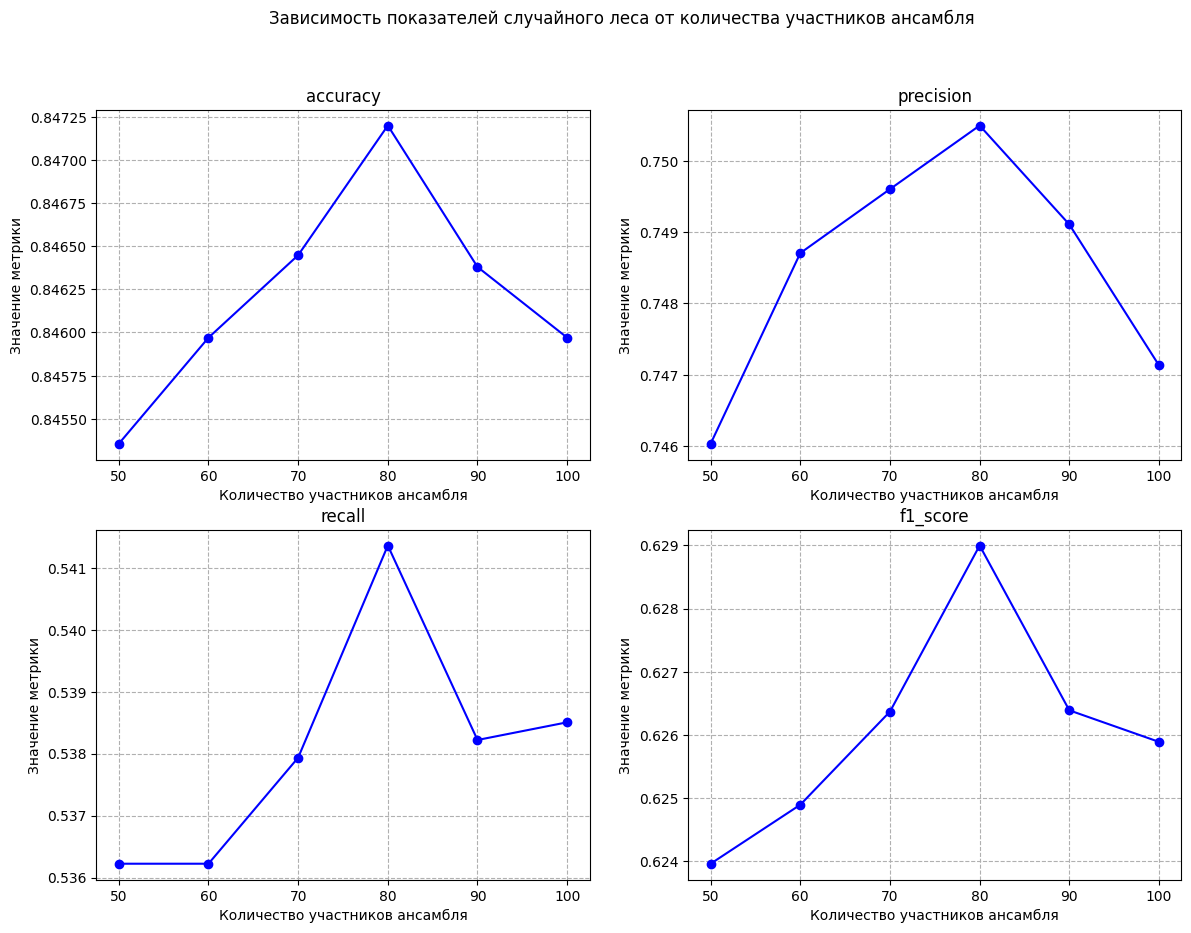

In [215]:
decicion_tree_metrics = {
    'accuracy': 0.7187020165830689,
    'precision': 0.4531321444901692,
    'recall': 0.8477331052181352,
    'f1_score': 0.5905840286054828
}

list_of_max_participants = list(range(50, 101, 10))
visualiser = Visualiser()

model_type = 'random_forest'

for max_participants in list_of_max_participants:
    local_metrics = сonduct_experiment(
        model_type, 
        max_participants=max_participants,
        print_metrics=False,
        visualise_conf_matrix=False
    )

    visualiser.add_metrics(local_metrics)

visualiser.visualise_metrics(
    X=list_of_max_participants,
    suptitle='Зависимость показателей случайного леса от количества участников ансамбля',
    xlabel='Количество участников ансамбля',
)

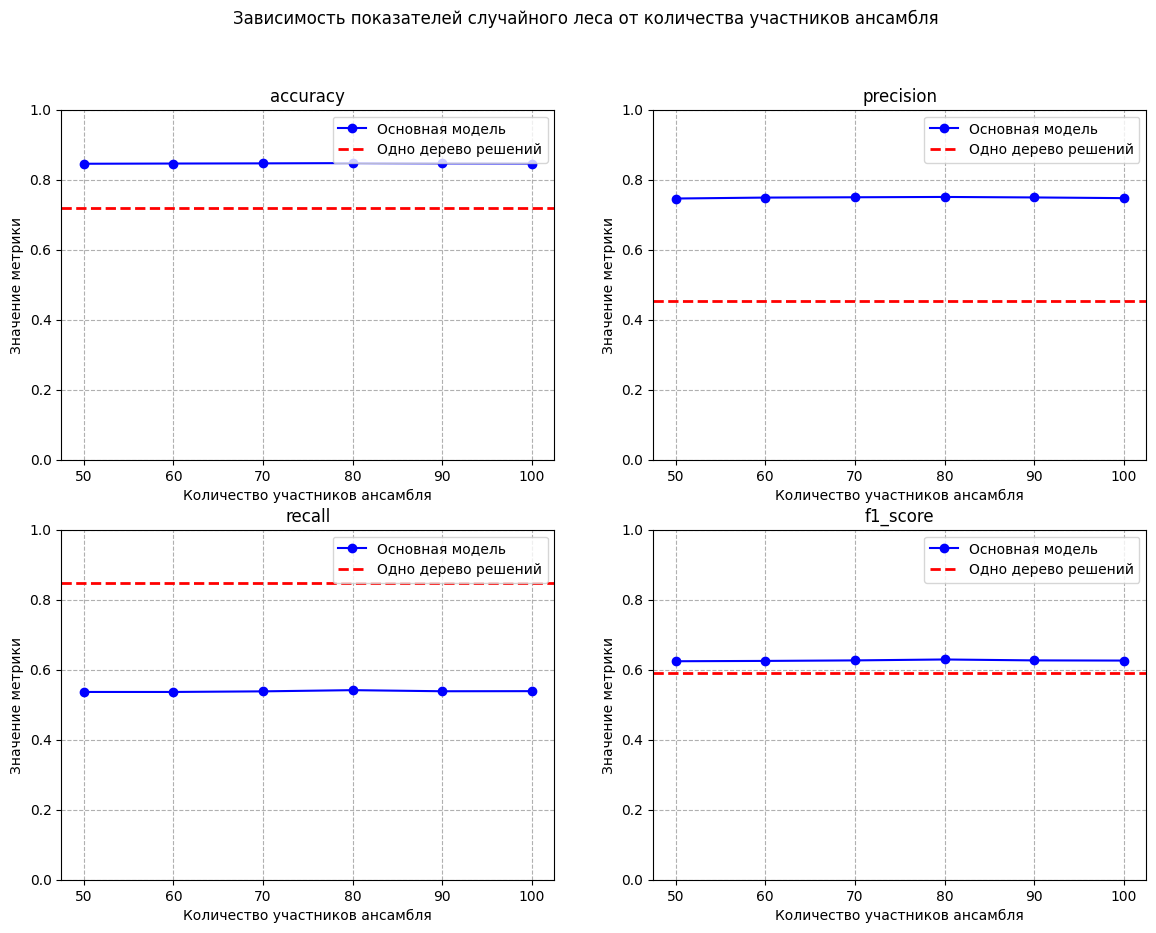

In [216]:
visualiser.visualise_metrics(
    X=list_of_max_participants,
    suptitle='Зависимость показателей случайного леса от количества участников ансамбля',
    xlabel='Количество участников ансамбля',
    pin_other_metric=decicion_tree_metrics,
    other_metric_label='Одно дерево решений',
    set_y_lim=True
)